# Machine learning supervisado

### Implementación de Modelos de Machine Learning

En esta sección, aplicamos modelos de machine learning supervisado para analizar las diferencias entre los datos catastrales oficiales y la información de Google Open Buildings en los municipios de Aipe y Gigante. Usaremos Árboles de Decisión, Random Forest y XGBoost, tres algoritmos basados en árboles, para clasificar las edificaciones según su nivel de cambio.

In [ ]:
import geopandas as gpd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

Se cargan los datos de edificaciones procesadas para los municipios de Gigante y Aipe desde archivos GeoJSON. Para facilitar el análisis, combinamos ambos conjuntos de datos en un solo GeoDataFrame

In [ ]:
archivos=["https://raw.githubusercontent.com/Luisafrodriguezo1/Diplomado2025/c9269f0fa7f55cf656b6249b73ea6a44fce9bc50/20241114_GIGANTE_building_procesado2_label.geojson",

          "https://raw.githubusercontent.com/Luisafrodriguezo1/Diplomado2025/c9269f0fa7f55cf656b6249b73ea6a44fce9bc50/20241214_AIPE_building_procesado2_label.geojson"]

In [ ]:
gdfs=[]
for geojson in archivos:
    #ruta = os.path.join(directorio, geojson)
    ruta = os.path.join( geojson)
    gdf = gpd.read_file(  ruta)
    gdfs.append(gdf)

gdf_concat=gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True))

In [ ]:
gdf_concat

,id,UOI_max,Hausdorff_Distance,neighbors_count,Centroid_Distance,google_mbr_angle_deg,google_mbr_direction,catastro_mbr_angle_deg,catastro_mbr_direction,google_custom_angle_deg,...,google_centroid_y,catastro_centroid_x,catastro_centroid_y,hausdorff_to_combined,intersections,intersected_area,area_in_meters,perimeter,LABEL_FINAL,geometry
0,413061,0.000000,1003.000000,0,-1.000000,NaN,None,NaN,None,NaN,...,1.832932e+06,0.000000e+00,0.000000e+00,-1.000000,NaN,0.000000,23.344865,19.388882,0,"POLYGON ((4714505.149 1832935.353, 4714508.722..."
1,413062,0.336396,5.244896,3,3.117759,150.803488,right,144.508134,right,59.653707,...,1.833855e+06,4.716547e+06,1.833852e+06,4.313561,2.0,164.326415,222.473820,60.211632,2,"POLYGON ((4716542.982 1833864.368, 4716557.884..."
2,413063,0.000000,1003.000000,0,-1.000000,NaN,None,NaN,None,NaN,...,1.834906e+06,0.000000e+00,0.000000e+00,-1.000000,NaN,0.000000,62.778679,31.967788,0,"POLYGON ((4717560.603 1834902.042, 4717554.037..."
3,413064,0.000000,1003.000000,0,-1.000000,NaN,None,NaN,None,NaN,...,1.833813e+06,0.000000e+00,0.000000e+00,-1.000000,NaN,0.000000,16.268728,16.177043,0,"POLYGON ((4721909.092 1833815.542, 4721910.277..."
4,413065,0.343717,15.427753,1,5.366902,178.111779,right,87.862900,right,63.170795,...,1.830154e+06,4.714821e+06,1.830152e+06,15.427753,1.0,199.543511,245.481629,80.380421,2,"POLYGON ((4714826.198 1830161.256, 4714826.176..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20972,410168689,0.000000,25.701070,1,14.338354,81.586189,right,84.685289,right,81.585328,...,1.914417e+06,0.000000e+00,0.000000e+00,-1.000000,NaN,0.000000,41.364741,25.733700,0,"POLYGON Z ((4751781.023 1914413.484 0, 4751774..."
20973,410168690,0.545187,3.457844,3,0.566331,8.141483,right,7.823657,right,8.141483,...,1.914108e+06,4.750914e+06,1.914108e+06,3.457844,1.0,183.950073,337.407129,86.101342,2,"POLYGON Z ((4750930.766 1914105.477 0, 4750898..."
20974,410168691,0.228520,57.049541,4,36.502694,6.072390,right,8.036513,right,6.072390,...,1.914022e+06,4.751561e+06,1.914023e+06,57.049541,1.0,162.179418,185.041496,58.626741,2,"POLYGON Z ((4751607.896 1914018.304 0, 4751587..."
20975,410168692,0.000000,1003.000000,10,-1.000000,NaN,None,NaN,None,NaN,...,1.914115e+06,0.000000e+00,0.000000e+00,-1.000000,NaN,0.000000,51.118718,30.691467,0,"POLYGON Z ((4751310.576 1914110.196 0, 4751305..."


In [ ]:
gdf_concat.columns

Index(['id', 'UOI_max', 'Hausdorff_Distance', 'neighbors_count',
       'Centroid_Distance', 'google_mbr_angle_deg', 'google_mbr_direction',
       'catastro_mbr_angle_deg', 'catastro_mbr_direction',
       'google_custom_angle_deg', 'google_custom_direction',
       'catastro_custom_angle_deg', 'catastro_custom_direction',
       'adjusted_catastro_mbr_angle', 'angle_difference',
       'custom_angle_difference', 'num_intersections', 'combined_area',
       'combined_area_intersections', 'combined_UOI', 'union_area',
       'google_area_minus_inters', 'google_centroid_x', 'google_centroid_y',
       'catastro_centroid_x', 'catastro_centroid_y', 'hausdorff_to_combined',
       'intersections', 'intersected_area', 'area_in_meters', 'perimeter',
       'LABEL_FINAL', 'geometry'],
      dtype='object')

Se exploran varias columnas que nos permiten comparar las edificaciones de Google Open Buildings con el catastro. Algunas  son:

`Hausdorff_Distance`: Mide la mayor distancia entre los bordes de un polígono de Google y su par más cercano en catastro. Un valor alto sugiere diferencias significativas en forma.

`Centroid_Distance`: Indica qué tan alejados están los centroides de los edificios en ambas fuentes.

`num_intersections`: Cuenta cuántas intersecciones existen entre los polígonos.

`combined_UOI` (Unión sobre Intersección combinada): Relación entre el área superpuesta y la unión total de ambos polígonos.

`LABEL_FINAL`: Clasifica los cambios en tres niveles (0: cambio significativo, 1: cambio moderado, 2: sin cambio).

In [ ]:
gdf_concat.shape

(20977, 33)

El dataset consolidado `gdf_concat` contiene 20,977 registros y 33 característica

In [ ]:
gdf_concat.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 20977 entries, 0 to 20976
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   id                           20977 non-null  object  
 1   UOI_max                      20977 non-null  float64 
 2   Hausdorff_Distance           20977 non-null  float64 
 3   neighbors_count              20977 non-null  int32   
 4   Centroid_Distance            20977 non-null  float64 
 5   google_mbr_angle_deg         13521 non-null  float64 
 6   google_mbr_direction         13521 non-null  object  
 7   catastro_mbr_angle_deg       13521 non-null  float64 
 8   catastro_mbr_direction       13521 non-null  object  
 9   google_custom_angle_deg      13354 non-null  float64 
 10  google_custom_direction      13521 non-null  object  
 11  catastro_custom_angle_deg    13333 non-null  float64 
 12  catastro_custom_direction    13521 non-null  object 

El dataset tiene principalmente variables numéricas, pero las columnas relacionadas con dirección `*_direction` son de tipo objeto, lo que sugiere valores categóricos

In [ ]:
gdf_concat[gdf_concat['LABEL_FINAL'].isna()]

,id,UOI_max,Hausdorff_Distance,neighbors_count,Centroid_Distance,google_mbr_angle_deg,google_mbr_direction,catastro_mbr_angle_deg,catastro_mbr_direction,google_custom_angle_deg,...,google_centroid_y,catastro_centroid_x,catastro_centroid_y,hausdorff_to_combined,intersections,intersected_area,area_in_meters,perimeter,LABEL_FINAL,geometry


In [ ]:
gdf_concat['LABEL_FINAL'].value_counts()

,count
LABEL_FINAL,
2,10872
0,8367
1,1738


`LABEL_FINAL` no tiene valores nulos, garantiza que todas las muestras están etiquetadas para el modelo supervisado. Sin embargo, existe un desequilibrio de clases, con mayoría en "No hay cambio" (2) y pocos en "Cambio moderado" (1). Se debe considerar técnicas de balanceo para evitar sesgos en el modelo.

### División del conjunto de Datos

 **Variables predictoras (`X`)**:  
  Se excluyen `LABEL_FINAL` (variable de respuesta), `id` (identificador) y `geometry` (no útil para modelos numéricos), dejando solo las características relevantes para la predicción.  

- **Variable de respuesta (`y`)**:  
  `LABEL_FINAL`, que clasifica los cambios en las edificaciones. Se convierte a entero para el modelo supervisado.  

- **División de datos**:  
  Se usa `train_test_split` con 80% para entrenamiento y 20% para prueba.

In [ ]:
 #Variables predictoras,variable de respuesta y id
X = gdf_concat.drop(columns=['LABEL_FINAL', 'id', 'geometry'])
y = gdf_concat['LABEL_FINAL'].astype(int)

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test, ids_train, ids_test, geometries_train, geometries_test = train_test_split(
X, y, gdf_concat['id'], gdf_concat['geometry'], test_size=0.2, random_state=42)

In [ ]:
print("Conjunto de datos",gdf_concat.shape)
print("Variales predictorias",X_train.shape,X_test.shape)
print("Variable respuesta",y_train.shape,y_test.shape)
print("Id",ids_train.shape,ids_test.shape)
print("Geométria",geometries_train.shape,geometries_test.shape)

Conjunto de datos (20977, 33)
Variales predictorias (16781, 30) (4196, 30)
Variable respuesta (16781,) (4196,)
Id (16781,) (4196,)
Geométria (16781,) (4196,)


 Las columnas categóricas eran de tipo `object`, lo que requiere convertirlas a valores numéricos para que los modelos de Machine Learning puedan procesarlas. Se emplea `LabelEncoder` para asignar un número entero a cada categoría única en las columnas categóricas.Aunque las columnas ya eran `object`, se aplica `astype(str)` para evitar problemas con valores `NaN` u otros formatos inesperados.  

In [ ]:
from sklearn.preprocessing import LabelEncoder

columnas_categoricas = [ 'google_mbr_direction', 'catastro_mbr_direction', 'google_custom_direction', 'catastro_custom_direction']

label_encoders = {}
for columna in columnas_categoricas:
    if columna in X_train.columns:
        le = LabelEncoder()
        X_train[columna] = le.fit_transform(X_train[columna].astype(str))
        X_test[columna] = le.transform(X_test[columna].astype(str))
        label_encoders[columna] = le

In [ ]:
for columna, le in label_encoders.items():
    print(f"Columna: {columna}")
    print(dict(zip(le.classes_, le.transform(le.classes_))))  # Mapeo de valores originales a números
    print("-" * 50)

Columna: google_mbr_direction
{'None': np.int64(0), 'right': np.int64(1)}
--------------------------------------------------
Columna: catastro_mbr_direction
{'None': np.int64(0), 'right': np.int64(1)}
--------------------------------------------------
Columna: google_custom_direction
{'None': np.int64(0), 'right': np.int64(1), 'undefined': np.int64(2)}
--------------------------------------------------
Columna: catastro_custom_direction
{'None': np.int64(0), 'right': np.int64(1), 'undefined': np.int64(2)}
--------------------------------------------------


### Entrenamiento árbol de decisión

Se define un Árbol de Decisión (DecisionTreeClassifier) con una profundidad máxima de 3 (max_depth=3) para evitar sobreajuste. Ademas,establece una semilla (random_state=42) para garantizar que el modelo siempre produzca los mismos resultados cuando se vuelve a entrenar con los mismos datos.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=42, max_depth=3)
clf.fit(X_train, y_train)

# Hace predicciones
y_pred = clf.predict(X_test)

# Evalua el modelo
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1684
           1       0.62      0.03      0.05       318
           2       0.86      1.00      0.92      2194

    accuracy                           0.91      4196
   macro avg       0.82      0.66      0.65      4196
weighted avg       0.90      0.91      0.88      4196



In [ ]:
criterion='entropy'

Se observa que:
* El modelo tiene un alto rendimiento en las clases 0 y 2, pero falla gravemente en la clase 1.
* El recall de la clase 1 es extremadamente bajo (0.03), lo que significa que el modelo apenas la detecta.
* El accuracy general es 0.91, pero debido al desbalance, este valor puede ser engañoso.

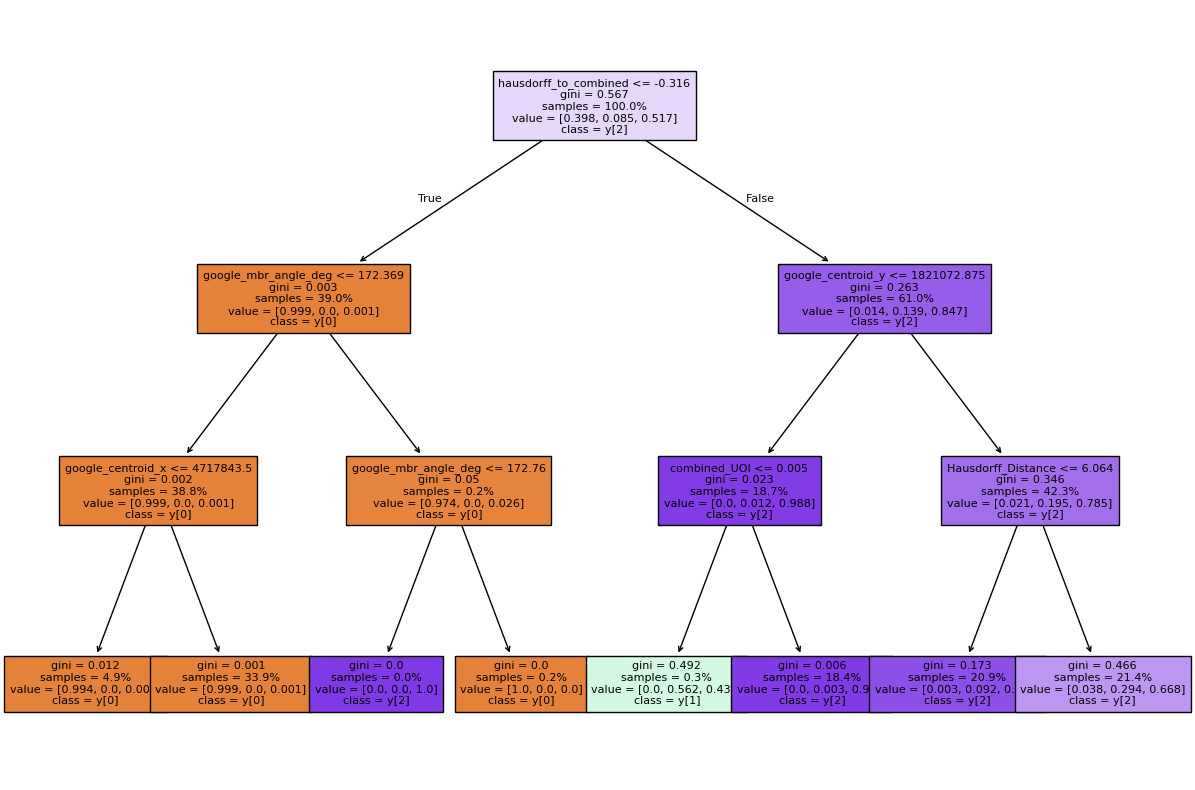

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
plt.figure(figsize=(15, 10))  # Tamaño de la imagen
plot_tree(clf, feature_names=X_train.columns, class_names=True, filled=True, fontsize=8, proportion=True)
plt.show()

### Entrenamiento árbol de decisión balanceado

Se utiliza `class_weight="balanced"` para corregir posibles desbalances en las clases, ajustando automáticamente los pesos según su frecuencia en los datos de entrenamiento.

In [ ]:

clf_bal = DecisionTreeClassifier(random_state=42, max_depth=3,class_weight="balanced")
clf_bal.fit(X_train, y_train)


y_pred_bal = clf_bal.predict(X_test)


print(classification_report(y_test, y_pred_bal))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1684
           1       0.25      0.87      0.39       318
           2       0.97      0.64      0.77      2194

    accuracy                           0.79      4196
   macro avg       0.74      0.83      0.71      4196
weighted avg       0.93      0.79      0.83      4196



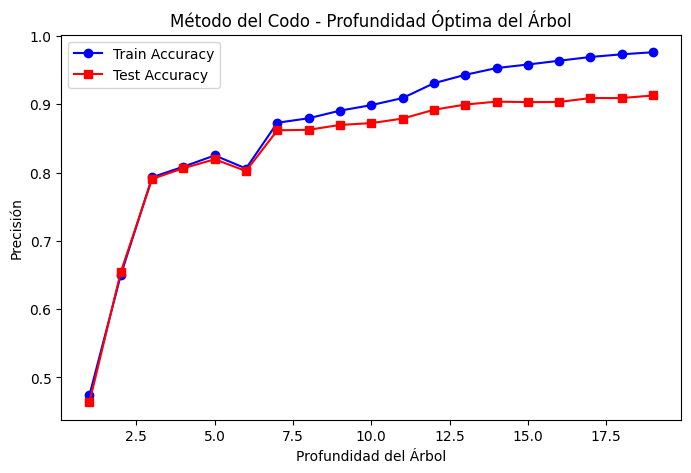

In [ ]:
from sklearn.metrics import accuracy_score

train_acc = []
test_acc = []
max_depths = range(1, 20)  # Probar profundidades de 1 a 20

for depth in max_depths:
    clf1 = DecisionTreeClassifier(max_depth=depth, random_state=42,class_weight="balanced")
    clf1.fit(X_train, y_train)

    train_acc.append(accuracy_score(y_train, clf1.predict(X_train)))  # Precisión en entrenamiento
    test_acc.append(accuracy_score(y_test, clf1.predict(X_test)))  # Precisión en prueba

# Graficar el método del codo
plt.figure(figsize=(8, 5))
plt.plot(max_depths, train_acc, marker='o', label="Train Accuracy", color='blue')
plt.plot(max_depths, test_acc, marker='s', label="Test Accuracy", color='red')
plt.xlabel("Profundidad del Árbol")
plt.ylabel("Precisión")
plt.legend()
plt.title("Método del Codo - Profundidad Óptima del Árbol")
plt.show()

El gráfico muestra el método del codo para determinar la profundidad óptima de un árbol de decisión en un modelo de clasificación. En el **eje x** se representa la profundidad del árbol, mientras que en el **eje y** se muestra la precisión del modelo.

La **curva azul** indica la precisión en entrenamiento, que aumenta constantemente con la profundidad, mientras que la **curva roja** representa la precisión en prueba, la cual crece inicialmente pero luego se estabiliza. Un aumento excesivo en la profundidad puede llevar a sobreajuste, evidenciado por la creciente diferencia entre ambas curvas. Para evitarlo, se debe elegir una profundidad donde la precisión en prueba deje de mejorar significativamente; en este caso, un valor entre 8 y 10 parece adecuado, ya que después de este punto la precisión en prueba se estabiliza y el modelo podría ajustarse demasiado a los datos de entrenamiento.

### Entrenamiento RandomForest

Se implementa un modelo Random Forest, un número de 100 árboles (`n_estimators=100`) y una profundidad máxima de 10 (`max_depth=10`)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

clf_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42,oob_score=True)
clf_rf.fit(X_train, y_train)


y_pred = clf_rf.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión del modelo: {accuracy:.4f}')
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred))

Precisión del modelo: 0.9302

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1684
           1       0.71      0.27      0.39       318
           2       0.90      0.99      0.94      2194

    accuracy                           0.93      4196
   macro avg       0.87      0.75      0.77      4196
weighted avg       0.92      0.93      0.92      4196



In [ ]:
print(f"OOB Score: {clf_rf.oob_score_:.3f}")

OOB Score: 0.927


### Entrenamiento RandomForest balanceado

Se entrena un modelo Random Forest con balanceo de clases para mejorar la predicción en conjuntos de datos desbalanceados.

In [ ]:
from sklearn.ensemble import RandomForestClassifier


clf_rf_bl = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42,class_weight="balanced")
clf_rf_bl.fit(X_train, y_train)


y_pred = clf_rf_bl.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión del modelo: {accuracy:.4f}')
print('\n Reporte de clasificación:')
print(classification_report(y_test, y_pred))

Precisión del modelo: 0.8975

 Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1684
           1       0.41      0.80      0.55       318
           2       0.97      0.86      0.91      2194

    accuracy                           0.90      4196
   macro avg       0.79      0.87      0.81      4196
weighted avg       0.94      0.90      0.91      4196



Cuando trabajamos con datos desbalanceados, donde una clase tiene muchos más ejemplos que otra, los modelos tiende a favorecer la clase mayoritaria y a ignorar la minoritaria. Para corregir esto, una forma de corregirlo es usando `class_weight="balanced"`que:

* Reequilibra el modelo asignando pesos mayores a las clases menos representadas, asegurando que tengan un impacto significativo en el entrenamiento.
* Evita sesgos hacia la clase mayoritaria, permitiendo que el modelo preste más atención a las observaciones menos comunes.
* Mejora el rendimiento en problemas de desbalance, aumentando la capacidad del modelo para identificar correctamente casos de la clase minoritaria.

### Entrenamiento XGboost

 En este modelo, se usa  `multi:softmax` para clasificación multiclase, definiendo tres categorías con `num_class=3`y evaluando el rendimiento con `mloglos`s. Se activa `enable_categorical=True` para manejar variables categóricas sin preprocesamiento adicional y fijamos `random_state=42` para reproducibilidad.

In [ ]:
import xgboost as xgb

clf_xgb = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    enable_categorical=True
)

# Entrenar el modelo
clf_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=3, ...)

In [ ]:

y_pred = clf_xgb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión del modelo: {accuracy:.4f}')
print('\n Reporte de clasificación:')
print(classification_report(y_test, y_pred))

Precisión del modelo: 0.9366

 Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1684
           1       0.62      0.50      0.55       318
           2       0.93      0.96      0.95      2194

    accuracy                           0.94      4196
   macro avg       0.85      0.82      0.83      4196
weighted avg       0.93      0.94      0.93      4196



### Entrenamiento XGboost Balanceado

En XGBoost, la opción `class_weight="balanced"` no está disponible. Sin embargo, puede lograr el mismo efecto ajustando los pesos de las clases manualmente mediante sample_weight durante el entrenamiento.

In [ ]:
num_samples = {2: 10872, 0: 8367, 1: 1738}

N = sum(num_samples.values())
C = len(num_samples)

class_weights = {cls: N / (C * count) for cls, count in num_samples.items()}

print(f"Total de muestras (N): {N}")
print(f"Número de clases (C): {C}")
print("Pesos de clase calculados:")
for cls, weight in class_weights.items():
    print(f"Clase {cls}: {weight:.3f}")

Total de muestras (N): 20977
Número de clases (C): 3
Pesos de clase calculados:
Clase 2: 0.643
Clase 0: 0.836
Clase 1: 4.023


In [ ]:

clf_xgbb = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    enable_categorical=True
)
sample_weights = y_train.map(class_weights)


clf_xgbb.fit(X_train, y_train, sample_weight=sample_weights)

y_pred = clf_xgbb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión del modelo: {accuracy:.4f}')
print('\n Reporte de clasificación:')
print(classification_report(y_test, y_pred))

Precisión del modelo: 0.9342

 Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1684
           1       0.56      0.70      0.62       318
           2       0.96      0.93      0.94      2194

    accuracy                           0.93      4196
   macro avg       0.84      0.87      0.85      4196
weighted avg       0.94      0.93      0.94      4196

